<a href="https://colab.research.google.com/github/ranjithtg-omr/AI_ML_RANJITH/blob/main/Assignement4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this first
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
from google.colab import files

warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
#Load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test_tweets.csv')
sample = pd.read_csv('sample.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nLabel distribution:\n", train['label'].value_counts())

Train shape: (31962, 3)
Test shape: (17197, 2)

Label distribution:
 label
0    29720
1     2242
Name: count, dtype: int64


Exploratory Data Analysis (WordClouds)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

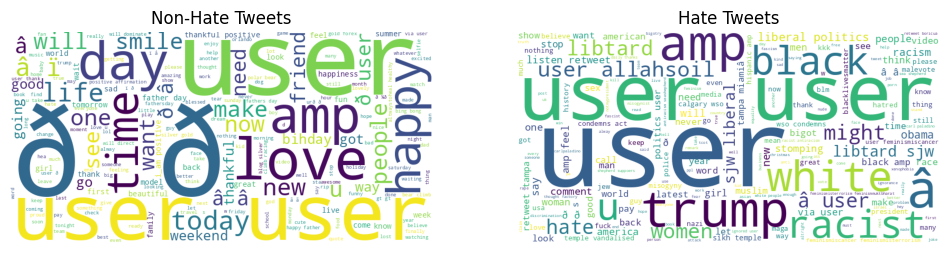

In [ ]:
# Combine all tweets for wordclouds
all_tweets = ' '.join(train['tweet'])

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
wc_nonhate = WordCloud(width=800, height=400, background_color='white').generate(' '.join(train[train['label']==0]['tweet']))
plt.imshow(wc_nonhate)
plt.title('Non-Hate Tweets')
plt.axis('off')

plt.subplot(1,2,2)
wc_hate = WordCloud(width=800, height=400, background_color='white').generate(' '.join(train[train['label']==1]['tweet']))
plt.imshow(wc_hate)
plt.title('Hate Tweets')
plt.axis('off')
plt.show()

Text Cleaning Function

In [ ]:
def clean_tweet(text):
    # 1. Remove @user mentions
    text = re.sub(r'@\w+', '', text)
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 3. Remove special characters, numbers, punctuations
    text = re.sub(r'[^a-zA-Z#]', ' ', text)
    # 4. Lowercase
    text = text.lower()
    # 5. Tokenize
    text = text.split()
    # 6. Remove stopwords + stemming
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    text = [ps.stem(word) for word in text if word not in stop_words]
    # 7. Join back
    return ' '.join(text)

# Apply cleaning
train['clean_tweet'] = train['tweet'].apply(clean_tweet)
test['clean_tweet'] = test['tweet'].apply(clean_tweet)

print("Cleaning done! Sample:")
print(train[['tweet', 'clean_tweet']].head())

Cleaning done! Sample:
                                               tweet  \
0   @user when a father is dysfunctional and is s...   
1  @user @user thanks for #lyft credit i can't us...   
2                                bihday your majesty   
3  #model   i love u take with u all the time in ...   
4             factsguide: society now    #motivation   

                                         clean_tweet  
0     father dysfunct selfish drag kid dysfunct #run  
1  thank #lyft credit use caus offer wheelchair v...  
2                                     bihday majesti  
3                       #model love u take u time ur  
4                           factsguid societi #motiv  


Feature Extraction (TF-IDF)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)

X = tfidf.fit_transform(train['clean_tweet']).toarray()
y = train['label'].values

# For test
X_test = tfidf.transform(test['clean_tweet']).toarray()

print("TF-IDF shape:", X.shape)

TF-IDF shape: (31962, 5000)


Train-Test Split + Model Training

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# Validation score
val_pred = model.predict(X_val)
print("F1 Score on Validation:", f1_score(y_val, val_pred))
print("Accuracy:", accuracy_score(y_val, val_pred))
print("\nClassification Report:\n", classification_report(y_val, val_pred))

F1 Score on Validation: 0.5889164598842018
Accuracy: 0.9222587204755202

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.96      5945
           1       0.47      0.79      0.59       448

    accuracy                           0.92      6393
   macro avg       0.73      0.86      0.77      6393
weighted avg       0.95      0.92      0.93      6393



Predict on Test Data & Create Submission

In [ ]:
test_pred = model.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'label': test_pred
})

submission.to_csv('test_predictions.csv', index=False)
print("Submission file created: test_predictions.csv")
print(submission['label'].value_counts())

Submission file created: test_predictions.csv
label
0    15070
1     2127
Name: count, dtype: int64


Download submission

In [ ]:
files.download('test_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>